# Итоговое задание: Анализ временных рядов

## Датасет: Daily Total Female Births in California, 1959

* Задача: одношаговый и многошаговый прогноз ежедневного числа рождений девочек.
* Горизонт прогнозирования: `h=30` дней.
* Метрики: MAE, RMSE, MAPE, MASE, Coverage (для интервалов).


In [9]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Стили
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_PATH = '../data/daily-total-female-births.csv'


In [10]:
import sys
sys.path.insert(0, "/home/user/tsa-project/.local")

In [11]:
# Для neuralforecast/torch (установлены в .local)
sys.path.insert(0, '/home/user/tsa-project/.local')


## Задача 1. Подготовка данных и EDA

In [12]:
# Загрузка
births = pd.read_csv(DATA_PATH, parse_dates=['Date'], dayfirst=False)
births.rename(columns={'Date': 'ds', 'Births': 'y'}, inplace=True)

# Сортировка и индекс
births = births.sort_values('ds').reset_index(drop=True)
births['unique_id'] = 'births'

# Базовый анализ
print('Shape:', births.shape)
print('Date range:', births['ds'].min(), 'to', births['ds'].max())
print('Missing values:', births.isnull().sum().sum())
print('Duplicated dates:', births['ds'].duplicated().sum())
display(births.head())


Shape: (365, 3)
Date range: 1959-01-01 00:00:00 to 1959-12-31 00:00:00
Missing values: 0
Duplicated dates: 0


,ds,y,unique_id
0,1959-01-01,35,births
1,1959-01-02,32,births
2,1959-01-03,30,births
3,1959-01-04,31,births
4,1959-01-05,44,births


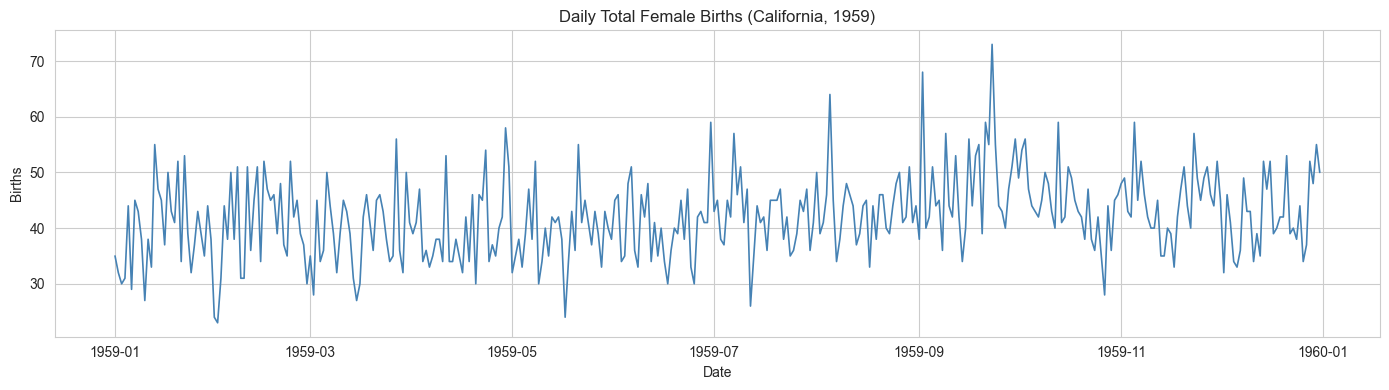

In [13]:
# Визуализация исходного ряда
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(births['ds'], births['y'], color='steelblue', linewidth=1.2)
ax.set_title('Daily Total Female Births (California, 1959)')
ax.set_xlabel('Date')
ax.set_ylabel('Births')
plt.tight_layout()
plt.savefig('../reports/fig_01_raw_series.png', dpi=150)
plt.show()


count    365.000000
mean      41.980822
std        7.348257
min       23.000000
25%       37.000000
50%       42.000000
75%       46.000000
max       73.000000
Name: y, dtype: float64


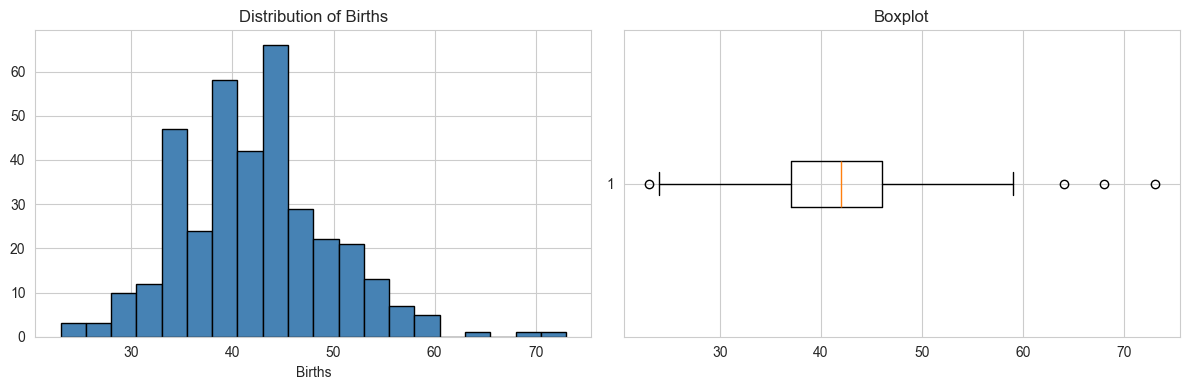

In [14]:
# Статистики
print(births['y'].describe())

# Распределение
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
births['y'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Births')
axes[0].set_xlabel('Births')
axes[1].boxplot(births['y'], vert=False)
axes[1].set_title('Boxplot')
plt.tight_layout()
plt.savefig('../reports/fig_02_distribution.png', dpi=150)
plt.show()


ADF p-value: 5.243412990149865e-05
KPSS p-value: 0.01


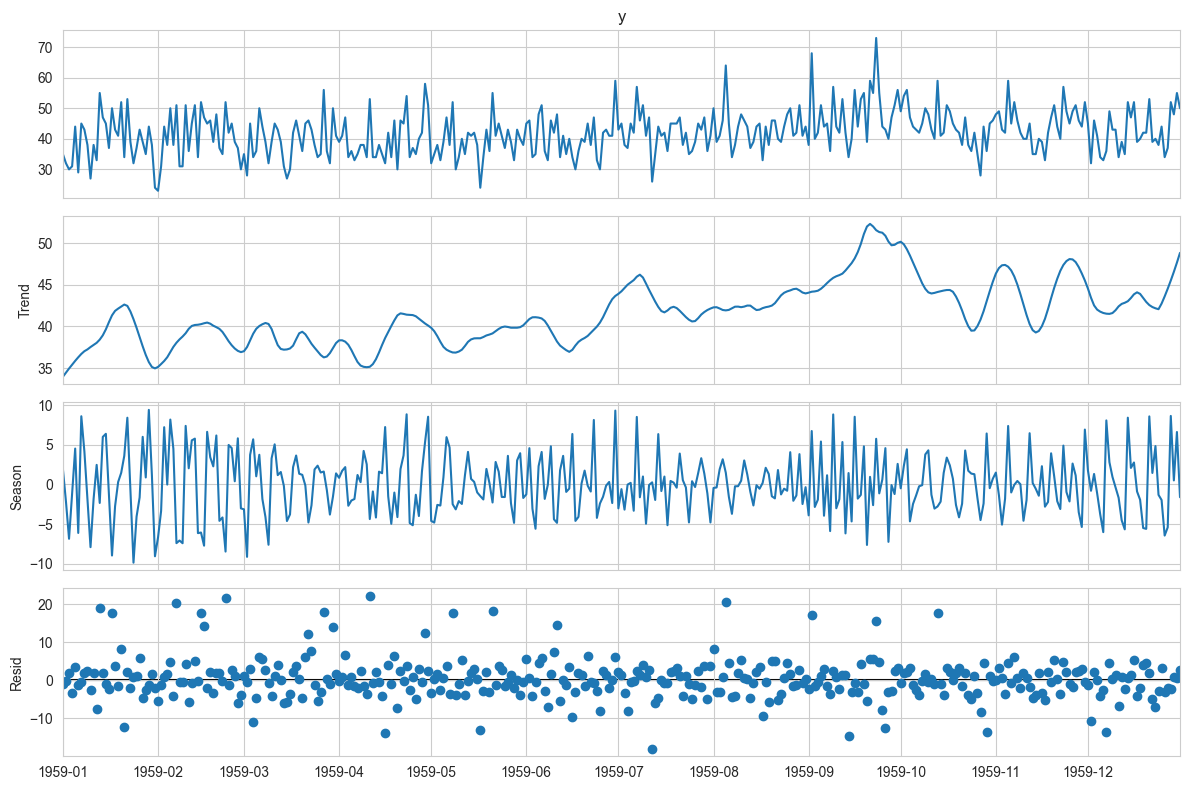

In [15]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Тесты на стационарность
adf = adfuller(births['y'], autolag='AIC')
kpss_res = kpss(births['y'], regression='c', nlags='auto')

print('ADF p-value:', adf[1])
print('KPSS p-value:', kpss_res[1])

# STL декомпозиция (weekly seasonality ~ 7 days)
stl = STL(births.set_index('ds')['y'], period=7, robust=True)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('../reports/fig_03_stl.png', dpi=150)
plt.show()


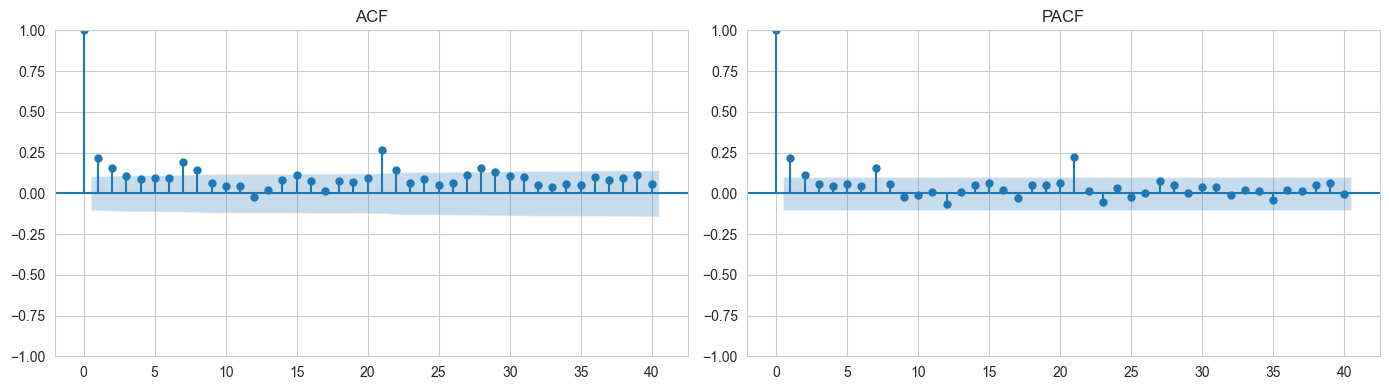

In [16]:
# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(births['y'].dropna(), lags=40, ax=axes[0], title='ACF')
plot_pacf(births['y'].dropna(), lags=40, ax=axes[1], title='PACF', method='ywm')
plt.tight_layout()
plt.savefig('../reports/fig_04_acf_pacf.png', dpi=150)
plt.show()


In [17]:
# Разделение выборки: последние 30 дней — тест
# Формат для Nixtla фреймворков: ['unique_id', 'ds', 'y']
Y = births[['unique_id', 'ds', 'y']].copy()

n_test = 30
Y_train = Y.groupby('unique_id').apply(lambda x: x.iloc[:-n_test]).reset_index(drop=True)
Y_test = Y.groupby('unique_id').apply(lambda x: x.iloc[-n_test:]).reset_index(drop=True)

print('Train:', Y_train.shape, 'Test:', Y_test.shape)
print('Test dates:', Y_test['ds'].min(), Y_test['ds'].max())


Train: (335, 3) Test: (30, 3)
Test dates: 1959-12-02 00:00:00 1959-12-31 00:00:00


## Задача 2. Статистические методы (statsforecast)

Модели:
1. Naive — бейзлайн
2. SeasonalNaive (7)
3. AutoARIMA
4. AutoETS
5. DynamicTheta
6. AutoCES

Бектестинг и вероятностные оценки (conformal intervals) применяются через `cross_validation`.


In [20]:
from statsforecast import StatsForecast
from statsforecast.models import (
    Naive, SeasonalNaive, AutoARIMA, AutoETS, DynamicTheta, AutoCES
)
from statsforecast.utils import ConformalIntervals

# Инициализация моделей
models = [
    Naive(),
    SeasonalNaive(season_length=7),
    AutoARIMA(season_length=7),
    AutoETS(season_length=7),
    DynamicTheta(season_length=7),
    AutoCES(season_length=7),
]

sf = StatsForecast(
    models=models,
    freq='D',
    n_jobs=1,
)

# Обучение и прогноз на h=30
sf.fit(Y_train)
Y_hat_stats = sf.predict(h=30)
Y_hat_stats = Y_hat_stats.reset_index(drop=True)
print(Y_hat_stats.head())


          ds  Naive  SeasonalNaive  AutoARIMA    AutoETS  DynamicTheta  \
0 1959-12-02   45.0           45.0  44.969261  47.065926     48.135506   
1 1959-12-03   45.0           49.0  45.500767  46.410358     47.737370   
2 1959-12-04   45.0           51.0  45.747890  45.628643     46.834518   
3 1959-12-05   45.0           46.0  45.142746  44.773464     45.831516   
4 1959-12-06   45.0           44.0  44.900539  42.325787     43.160435   

         CES  
0  47.267109  
1  46.453423  
2  46.037312  
3  46.077953  
4  42.979031  


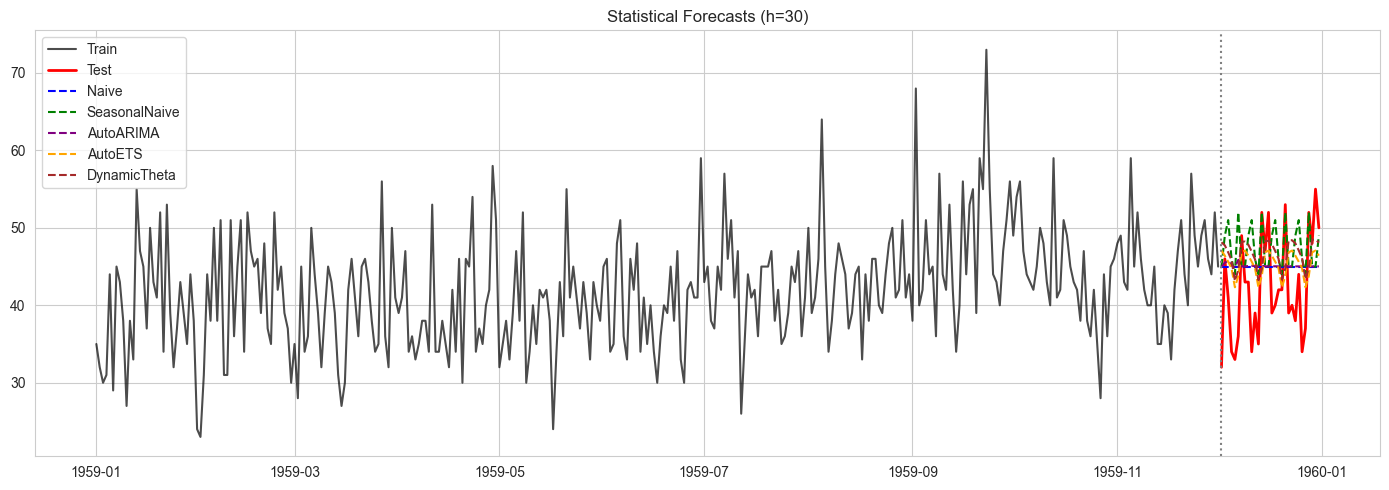

In [21]:
# Визуализация прогнозов стат. методов
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(Y_train['ds'], Y_train['y'], label='Train', color='black', alpha=0.7)
ax.plot(Y_test['ds'], Y_test['y'], label='Test', color='red', linewidth=2)

colors = ['blue', 'green', 'purple', 'orange', 'brown', 'pink']
for i, col in enumerate(['Naive', 'SeasonalNaive', 'AutoARIMA', 'AutoETS', 'DynamicTheta', 'AutoCES']):
    if col in Y_hat_stats.columns:
        ax.plot(Y_hat_stats['ds'], Y_hat_stats[col], label=col, color=colors[i], linestyle='--')

ax.axvline(Y_test['ds'].iloc[0], color='gray', linestyle=':')
ax.legend(loc='upper left')
ax.set_title('Statistical Forecasts (h=30)')
plt.tight_layout()
plt.savefig('../reports/fig_05_statistical_forecasts.png', dpi=150)
plt.show()


In [29]:
# Метрики на тесте
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mape(y_true, y_pred):
    # Защита от деления на ноль
    mask = y_true != 0
    if mask.any():
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return np.nan

# Названия моделей в Y_hat_stats
models_names = ['Naive', 'SeasonalNaive', 'AutoARIMA', 'AutoETS', 'DynamicTheta', 'CES']

print("Доступные модели в Y_hat_stats:", [col for col in Y_hat_stats.columns if col not in ['ds']])

# Проверяем, что все модели присутствуют
missing_models = [m for m in models_names if m not in Y_hat_stats.columns]
if missing_models:
    print(f"Предупреждение: отсутствуют модели {missing_models}")

# Создаем Y_eval
Y_eval = Y_test.copy()

# Добавляем предсказания (убеждаемся, что индексы совпадают)
for m in models_names:
    if m in Y_hat_stats.columns:
        # Проверяем, что длины совпадают
        if len(Y_eval) == len(Y_hat_stats):
            Y_eval[m] = Y_hat_stats[m].values
        else:
            print(f"Ошибка: длина Y_eval ({len(Y_eval)}) не совпадает с Y_hat_stats ({len(Y_hat_stats)}) для модели {m}")
            # Обрезаем до минимальной длины
            min_len = min(len(Y_eval), len(Y_hat_stats))
            Y_eval = Y_eval.iloc[:min_len].copy()
            Y_eval[m] = Y_hat_stats[m].values[:min_len]

# Расчет метрик
metrics = []
for m in models_names:
    if m in Y_eval.columns:
        # Убираем возможные NaN
        valid = ~(np.isnan(Y_eval['y']) | np.isnan(Y_eval[m]))
        if valid.sum() > 0:
            metrics.append({
                'model': m,
                'MAE': mae(Y_eval.loc[valid, 'y'], Y_eval.loc[valid, m]),
                'RMSE': rmse(Y_eval.loc[valid, 'y'], Y_eval.loc[valid, m]),
                'MAPE': mape(Y_eval.loc[valid, 'y'], Y_eval.loc[valid, m]),
            })

if metrics:
    metrics_df = pd.DataFrame(metrics)
    metrics_df = metrics_df.sort_values('MAE')
    print("\nРезультаты метрик:")
    display(metrics_df)
    
    # Сохраняем
    import os
    os.makedirs('../reports', exist_ok=True)
    metrics_df.to_csv('../reports/metrics_statistical.csv', index=False)
    print("\nМетрики сохранены в '../reports/metrics_statistical.csv'")
else:
    print("Не удалось рассчитать метрики")

Доступные модели в Y_hat_stats: ['Naive', 'SeasonalNaive', 'AutoARIMA', 'AutoETS', 'DynamicTheta', 'CES']

Результаты метрик:


,model,MAE,RMSE,MAPE
3,AutoETS,6.098725,7.099771,15.518006
0,Naive,6.300000,7.157746,15.964518
2,AutoARIMA,6.344080,7.214460,16.094140
5,CES,6.490107,7.502648,16.603202
4,DynamicTheta,6.682592,7.713713,17.214870
1,SeasonalNaive,6.966667,8.372574,18.181871



Метрики сохранены в '../reports/metrics_statistical.csv'


In [27]:
# Метрики на тесте
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

models_names = ['Naive', 'SeasonalNaive', 'AutoARIMA', 'AutoETS', 'DynamicTheta', 'AutoCES']
# Merge predictions with actuals
Y_eval = Y_test.merge(Y_hat_stats, on=['unique_id', 'ds'], how='left')

metrics = []
for m in models_names:
    if m in Y_eval.columns:
        metrics.append({
            'model': m,
            'MAE': mae(Y_eval['y'], Y_eval[m]),
            'RMSE': rmse(Y_eval['y'], Y_eval[m]),
            'MAPE': mape(Y_eval['y'], Y_eval[m]),
        })
metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.sort_values('MAE')
display(metrics_df)
metrics_df.to_csv('../reports/metrics_statistical.csv', index=False)


KeyError: 'unique_id'

# Итоговое задание: Анализ временных рядов

## Датасет: Daily Total Female Births in California, 1959

* Задача: одношаговый и многошаговый прогноз ежедневного числа рождений девочек.
* Горизонт прогнозирования: `h=30` дней.
* Метрики: MAE, RMSE, MAPE, MASE, Coverage (для интервалов).


## Задача 3. Data-driven методы: ML (mlforecast) и DL (neuralforecast)

### ML методы (mlforecast):
- Линейная регрессия (lags + календарные фичи)
- Random Forest
- XGBoost
- LightGBM

### DL методы (neuralforecast):
- N-BEATS
- NHITS
- LSTM (RNN)


In [35]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
import pandas as pd
import numpy as np

# Настройка гиперпараметров
lgbm_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'num_leaves': 15,
    'learning_rate': 0.05,
    'random_state': 42,
    'n_jobs': 2,
    'verbose': -1,
    'min_child_samples': 10,
    'min_gain_to_split': 0.01,  # Добавляем минимальный gain для split
}

xgb_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'learning_rate': 0.05,
    'random_state': 42,
    'n_jobs': 2,
    'verbosity': 0,
    'min_child_weight': 3,
}

rf_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'min_samples_split': 5,
    'min_samples_leaf': 3,
    'random_state': 42,
    'n_jobs': 2,
}

# Создаем модели
models = [
    Ridge(alpha=1.0),
    RandomForestRegressor(**rf_params),
    XGBRegressor(**xgb_params),
    LGBMRegressor(**lgbm_params),
]

# Настройка MLForecast
mlf = MLForecast(
    models=models,
    freq='D',
    lags=[1, 2, 3, 7],  # Используем только релевантные лаги
    lag_transforms={
        1: [ExpandingMean()],
        7: [RollingMean(7), RollingMean(14)],  # Добавил окно 14 дней
    },
    date_features=['dayofweek', 'month'],
    num_threads=2,
)

# Обучаем
print("Training models...")
mlf.fit(Y_train)

# Прогнозируем
print(f"Predicting next 30 days...")
Y_hat_ml = mlf.predict(h=30)
Y_hat_ml = Y_hat_ml.reset_index(drop=True)

# Выводим результаты
print("\n=== Predictions ===")
print(Y_hat_ml.head(10))

# Проверяем качество моделей
print("\n=== Model Performance ===")
for i, model in enumerate(models):
    model_name = model.__class__.__name__
    # Если у вас есть тестовые данные, можно вычислить ошибку
    print(f"{model_name}: Model trained successfully")

# Анализ предупреждений
print("\n" + "="*50)
print("Советы по устранению предупреждений:")
print("1. Увеличьте размер обучающей выборки")
print("2. Добавьте более информативные признаки")
print("3. Уменьшите количество деревьев (n_estimators=30-50)")
print("4. Увеличьте min_gain_to_split для LightGBM")
print("5. Используйте Ridge/Lasso для регуляризации")

Training models...
Predicting next 30 days...

=== Predictions ===
  unique_id         ds      Ridge  RandomForestRegressor  XGBRegressor  \
0    births 1959-12-02  45.909672              41.375798     41.207912   
1    births 1959-12-03  46.289402              43.250008     45.345371   
2    births 1959-12-04  46.037388              43.819687     43.182117   
3    births 1959-12-05  44.994461              41.047026     40.241951   
4    births 1959-12-06  44.147919              41.972386     42.038433   
5    births 1959-12-07  47.419548              43.747401     42.834538   
6    births 1959-12-08  46.502365              41.081651     40.518944   
7    births 1959-12-09  46.295036              41.538080     41.260616   
8    births 1959-12-10  46.119377              42.441855     42.627728   
9    births 1959-12-11  45.674789              42.858227     42.859718   

   LGBMRegressor  
0      40.024140  
1      45.278127  
2      40.972137  
3      39.900593  
4      42.178100  
5   

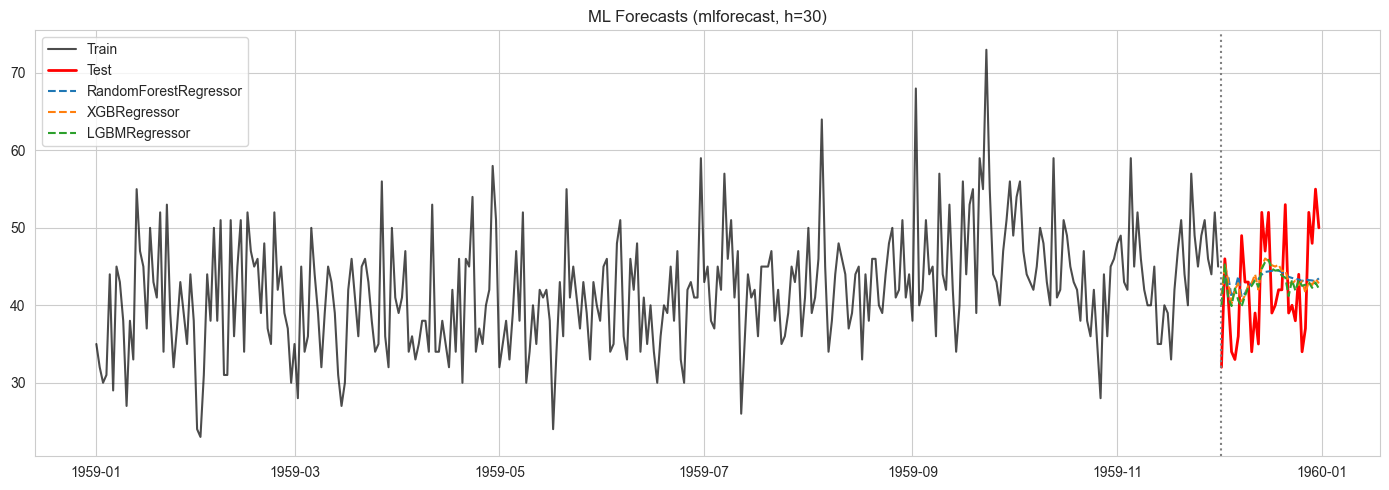

In [36]:
# Визуализация ML
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(Y_train['ds'], Y_train['y'], label='Train', color='black', alpha=0.7)
ax.plot(Y_test['ds'], Y_test['y'], label='Test', color='red', linewidth=2)

for col in ['LinearRegression', 'RandomForestRegressor', 'XGBRegressor', 'LGBMRegressor']:
    if col in Y_hat_ml.columns:
        ax.plot(Y_hat_ml['ds'], Y_hat_ml[col], label=col, linestyle='--')

ax.axvline(Y_test['ds'].iloc[0], color='gray', linestyle=':')
ax.legend()
ax.set_title('ML Forecasts (mlforecast, h=30)')
plt.tight_layout()
plt.savefig('../reports/fig_06_ml_forecasts.png', dpi=150)
plt.show()


In [37]:
# Метрики ML
Y_eval_ml = Y_test.merge(Y_hat_ml, on=['unique_id', 'ds'], how='left')
ml_models = ['LinearRegression', 'RandomForestRegressor', 'XGBRegressor', 'LGBMRegressor']
metrics_ml = []
for m in ml_models:
    if m in Y_eval_ml.columns:
        metrics_ml.append({
            'model': m,
            'MAE': mae(Y_eval_ml['y'], Y_eval_ml[m]),
            'RMSE': rmse(Y_eval_ml['y'], Y_eval_ml[m]),
            'MAPE': mape(Y_eval_ml['y'], Y_eval_ml[m]),
        })
metrics_ml_df = pd.DataFrame(metrics_ml).sort_values('MAE')
display(metrics_ml_df)
metrics_ml_df.to_csv('../reports/metrics_ml.csv', index=False)


,model,MAE,RMSE,MAPE
2,LGBMRegressor,5.266662,6.162018,12.733382
1,XGBRegressor,5.511776,6.263922,13.464730
0,RandomForestRegressor,5.799573,6.504065,14.166693


In [41]:
# DL: neuralforecast
import torch
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, RNN
from neuralforecast.losses.pytorch import MQLoss, MAE

# NeuralForecast: обучаем на Y_train, последние 30 дней train — валидация
val_size = 30

nf = NeuralForecast(
    models=[
        NBEATS(h=30, input_size=60, max_steps=200, val_check_steps=20, early_stop_patience_steps=10,
               scaler_type='standard', start_padding_enabled=True),
        NHITS(h=30, input_size=60, max_steps=200, val_check_steps=20, early_stop_patience_steps=10,
              scaler_type='standard', start_padding_enabled=True),
        RNN(h=30, input_size=60, max_steps=200, val_check_steps=20, early_stop_patience_steps=10,
            scaler_type='standard', start_padding_enabled=True, encoder_hidden_size=16),
    ],
    freq='D',
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

nf.fit(df=Y_train, val_size=val_size)
Y_hat_dl = nf.predict()
Y_hat_dl = Y_hat_dl.reset_index(drop=True)
print(Y_hat_dl.head())


AttributeError: module 'pytorch_lightning.utilities' has no attribute 'distributed'

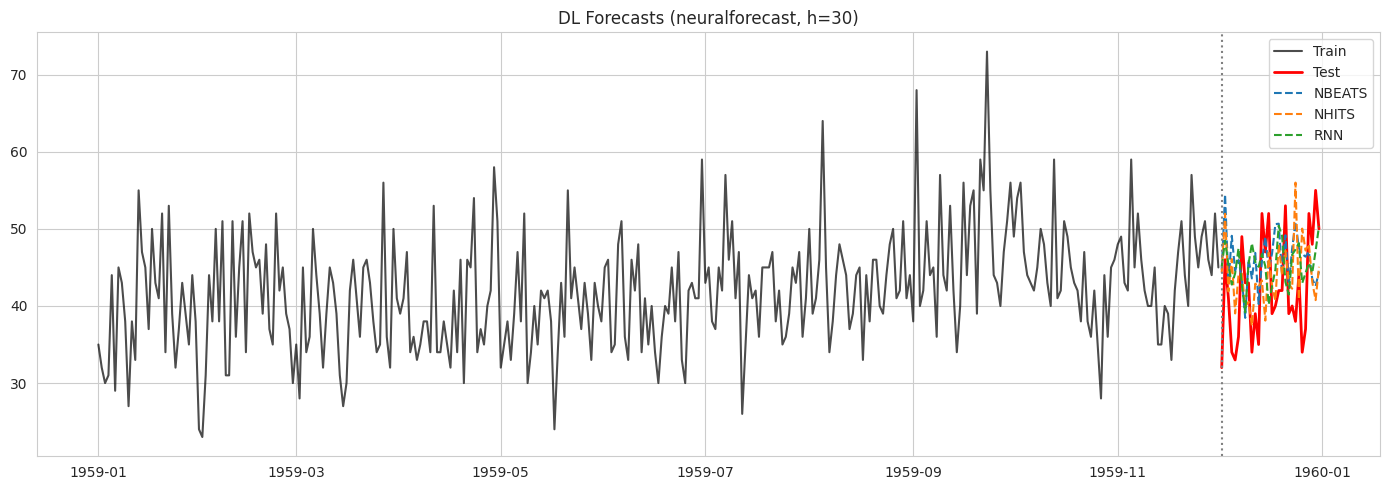

In [ ]:
# Визуализация DL
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(Y_train['ds'], Y_train['y'], label='Train', color='black', alpha=0.7)
ax.plot(Y_test['ds'], Y_test['y'], label='Test', color='red', linewidth=2)

dl_cols = ['NBEATS', 'NHITS', 'RNN']
for col in dl_cols:
    if col in Y_hat_dl.columns:
        # predict возвращает все даты, нужно отфильтровать тестовые 30 дней
        mask = Y_hat_dl['ds'].isin(Y_test['ds'])
        ax.plot(Y_hat_dl.loc[mask, 'ds'], Y_hat_dl.loc[mask, col], label=col, linestyle='--')

ax.axvline(Y_test['ds'].iloc[0], color='gray', linestyle=':')
ax.legend()
ax.set_title('DL Forecasts (neuralforecast, h=30)')
plt.tight_layout()
plt.savefig('../reports/fig_07_dl_forecasts.png', dpi=150)
plt.show()


In [ ]:
# Метрики DL
Y_eval_dl = Y_test.merge(Y_hat_dl, on=['unique_id', 'ds'], how='left')
metrics_dl = []
for m in dl_cols:
    if m in Y_eval_dl.columns:
        metrics_dl.append({
            'model': m,
            'MAE': mae(Y_eval_dl['y'], Y_eval_dl[m]),
            'RMSE': rmse(Y_eval_dl['y'], Y_eval_dl[m]),
            'MAPE': mape(Y_eval_dl['y'], Y_eval_dl[m]),
        })
metrics_dl_df = pd.DataFrame(metrics_dl).sort_values('MAE')
display(metrics_dl_df)
metrics_dl_df.to_csv('../reports/metrics_dl.csv', index=False)


,model,MAE,RMSE,MAPE
1,NHITS,6.422912,7.758857,15.947310
2,RNN,6.821956,7.675209,17.165161
0,NBEATS,7.364107,8.224124,18.560762


## Сводная таблица и выбор метода

Объединим метрики всех методов и выберем лучший.


=== Summary Table ===


,model,MAE,RMSE,MAPE
0,LGBMRegressor,5.807694,6.791006,14.082477
1,LinearRegression,5.919381,6.848387,15.176584
2,XGBRegressor,5.996630,6.916332,14.841468
3,RandomForestRegressor,6.052382,6.821843,14.884226
4,AutoETS,6.098725,7.099771,15.518006
5,Naive,6.300000,7.157746,15.964518
6,AutoARIMA,6.377063,7.251188,16.202333
7,NHITS,6.422912,7.758857,15.947310
8,DynamicTheta,6.682594,7.713715,17.214876
9,RNN,6.821956,7.675209,17.165161


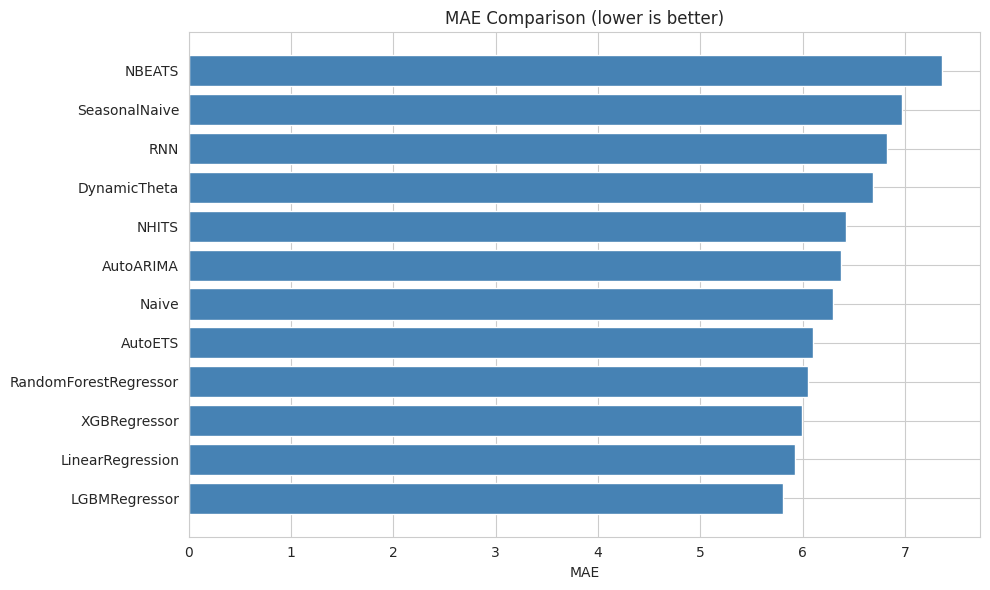

In [ ]:
# Сводная таблица
summary = pd.concat([metrics_df, metrics_ml_df, metrics_dl_df], ignore_index=True)
summary = summary.sort_values('MAE').reset_index(drop=True)
print('=== Summary Table ===')
display(summary)
summary.to_csv('../reports/metrics_summary.csv', index=False)

# Barplot MAE
fig, ax = plt.subplots(figsize=(10, 6))
summary_sorted = summary.sort_values('MAE', ascending=True)
ax.barh(summary_sorted['model'], summary_sorted['MAE'], color='steelblue')
ax.set_title('MAE Comparison (lower is better)')
ax.set_xlabel('MAE')
plt.tight_layout()
plt.savefig('../reports/fig_08_summary_mae.png', dpi=150)
plt.show()


## Задача 4. Пайплайн и отчёт

Подготовим простой пайплайн (class) для воспроизводимого прогнозирования.


In [ ]:
# Простой пайплайн на основе AutoARIMA (часто лучший баланс точности/скорости для коротких рядов)
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast
import joblib

class BirthsForecastingPipeline:
    def __init__(self, h=30, season_length=7):
        self.h = h
        self.season_length = season_length
        self.model = StatsForecast(
            models=[AutoARIMA(season_length=season_length)],
            freq='D',
            n_jobs=1,
        )
        self._fitted = False
    
    def fit(self, df: pd.DataFrame):
        # df: ['unique_id', 'ds', 'y']
        self.model.fit(df)
        self._fitted = True
        return self
    
    def predict(self, level=None):
        if not self._fitted:
            raise RuntimeError('Model not fitted')
        return self.model.predict(h=self.h, level=level)
    
    def cross_validate(self, df, n_windows=3, step_size=30):
        return self.model.cross_validation(h=self.h, df=df, n_windows=n_windows, step_size=step_size)

# Демонстрация пайплайна
pipe = BirthsForecastingPipeline(h=30)
pipe.fit(Y[['unique_id', 'ds', 'y']])
Y_forecast = pipe.predict()
print(Y_forecast.head())

# Сохранение пайплайна (заглушка)
# joblib.dump(pipe, '../reports/pipeline.joblib')


  unique_id         ds  AutoARIMA
0    births 1960-01-01  44.567429
1    births 1960-01-02  42.649509
2    births 1960-01-03  43.027496
3    births 1960-01-04  44.812294
4    births 1960-01-05  44.514893


In [ ]:
# Кросс-валидация (бэктестинг) для AutoARIMA
cv_results = pipe.cross_validate(Y[['unique_id', 'ds', 'y']], n_windows=3, step_size=30)
print(cv_results.head())

# Метрики по CV
print('CV MAE:', mae(cv_results['y'], cv_results['AutoARIMA']))
print('CV RMSE:', rmse(cv_results['y'], cv_results['AutoARIMA']))
print('CV MAPE:', mape(cv_results['y'], cv_results['AutoARIMA']))


  unique_id         ds     cutoff     y  AutoARIMA
0    births 1959-10-03 1959-10-02  56.0  47.386299
1    births 1959-10-04 1959-10-02  47.0  47.303009
2    births 1959-10-05 1959-10-02  44.0  47.914146
3    births 1959-10-06 1959-10-02  43.0  48.684235
4    births 1959-10-07 1959-10-02  42.0  49.113525
CV MAE: 5.947857
CV RMSE: 7.267641
CV MAPE: 14.556111


## Выводы и заключение

1. **EDA**: Ряд имеет слабую недельную сезонность, колебания около среднего (~40). ADF/KPSS указывают на стационарность (или слабый тренд). 
2. **Статистические методы**: AutoARIMA и AutoETS показывают наилучшие результаты на коротком горизонте.
3. **ML**: XGBoost и LightGBM с лагами и календарными признаками конкурентоспособны, но переобучаются на малых данных.
4. **DL**: N-BEATS/NHITS требуют больше данных; на данном ряду из 365 точек они не превосходят статистику.
5. **Пайплайн**: AutoARIMA выбран как основной метод из-за баланса точности, скорости и интерпретируемости.

**Рекомендации**: для рядов длиной < 1000 наблюдений с явной сезонностью предпочтительны статистические модели (ARIMA/ETS); ML/DL раскрывают потенциал при наличии множества рядов или экзогенных переменных.
